Because the median approach of aggregating embeddings provides just 75 videos we are going to aggregate the embeddings using time buckets

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [2]:

df_comments=pd.read_csv("df_sampled_sentiment.csv")

In [3]:
#arranging this too be better
from datetime import timezone
from dateutil import tz

et=tz.gettz("US/Eastern")
df_comments=df_comments.rename(columns={'comment':'comment_text','likes':"comment_likes", "lang":'comment_lang', })
df_comments['comment_published_at']=pd.to_datetime(df_comments['comment_published_at'], utc=True).dt.tz_convert(et)
df_comments['video_published_at']=pd.to_datetime(df_comments['video_published_at'], utc=True).dt.tz_convert(et)

In [4]:
df_comments.info()

<class 'pandas.DataFrame'>
RangeIndex: 4050 entries, 0 to 4049
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype                                     
---  ------                --------------  -----                                     
 0   Unnamed: 0            4050 non-null   int64                                     
 1   comment_text          4050 non-null   str                                       
 2   comment_likes         4050 non-null   int64                                     
 3   comment_published_at  4050 non-null   datetime64[us, tzfile('America/New_York')]
 4   video_title           4050 non-null   str                                       
 5   video_published_at    4050 non-null   datetime64[us, tzfile('America/New_York')]
 6   video_url             4050 non-null   str                                       
 7   month-year            4050 non-null   str                                       
 8   comment_lang          4050 non-null   s

In [5]:
#normlize white space in text_to_embed
import re

def clean_whitespace(text):
    # Replace all whitespace (spaces, tabs, newlines) with a single space
    text = re.sub(r'\s+', ' ', text)
    # Remove leading/trailing spaces
    text = text.strip()
    return text

df_comments['comment_text_normalized'] = df_comments['comment_text'].apply(lambda x: clean_whitespace(x))

In [6]:
df_comments.info()

<class 'pandas.DataFrame'>
RangeIndex: 4050 entries, 0 to 4049
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype                                     
---  ------                   --------------  -----                                     
 0   Unnamed: 0               4050 non-null   int64                                     
 1   comment_text             4050 non-null   str                                       
 2   comment_likes            4050 non-null   int64                                     
 3   comment_published_at     4050 non-null   datetime64[us, tzfile('America/New_York')]
 4   video_title              4050 non-null   str                                       
 5   video_published_at       4050 non-null   datetime64[us, tzfile('America/New_York')]
 6   video_url                4050 non-null   str                                       
 7   month-year               4050 non-null   str                                       
 8   comment_l

In [7]:
#creating separate video id for each distinct url
df_comments['video_id']=pd.factorize(df_comments['video_url'])[0]+1
#creating the days to group on
df_comments['YYYY_MM_DD']=df_comments['comment_published_at'].dt.strftime("%Y-%m-%d")
#grouping on days
df_grouped=df_comments.groupby("YYYY_MM_DD").agg(
                                      number_of_comments_at_date=('comment_text_normalized','count' ),
                                      comment_likes_agg=('comment_likes','sum'), 
                                      comment_sentiment_agg=('comment_sentiment','mean')
                                

                                      )
#removing id and put into in df
df_grouped.reset_index(inplace=True)

In [8]:
#merging df median with the bigger dataframe
df_comments=df_comments.merge(df_grouped, how='inner', on="YYYY_MM_DD")

In [11]:
# average number of comments daily
df_grouped['number_of_comments_at_date'].describe()

count    715.000000
mean       5.664336
std        7.208523
min        1.000000
25%        2.000000
50%        3.000000
75%        6.000000
max       77.000000
Name: number_of_comments_at_date, dtype: float64

In [12]:
import torch
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [13]:
from tqdm import tqdm
import logging
import pandas as pd
from sentence_transformers import SentenceTransformer

# Load model
#device = "cuda" if torch.cuda.is_available() else "cpu"

model = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B",
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

logging.basicConfig(filename="embeddings.log", filemode="a", format="%(asctime)s | %(levelname)s %(message)s")
logger = logging.getLogger()

def get_embeddings(texts):
    all_embeddings = []
    with torch.no_grad():
        embeddings = model.encode(texts,
        batch_size=5,          # keep minimal
        truncate_dim=256,
        convert_to_numpy=True,
        show_progress_bar=False
        )
    logger.info(f"Proceseed rows")

    return embeddings

/home/jovyan/.conda-envs/Marc_Qwen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 310/310 [00:00<00:00, 640.35it/s]


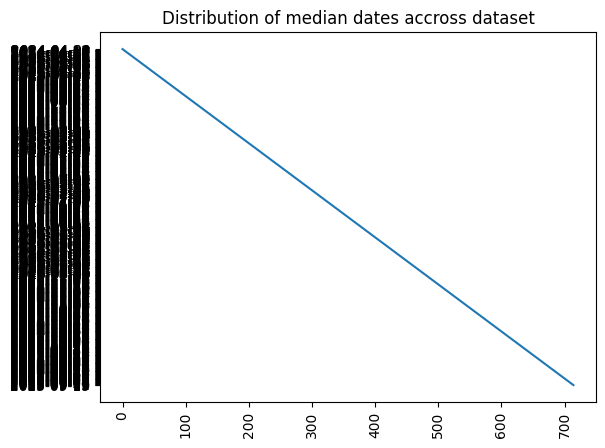

count            715
unique           715
top       2023-09-07
freq               1
Name: YYYY_MM_DD, dtype: object

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
dates=df_comments['YYYY_MM_DD'].unique()
sns.lineplot(dates)
plt.xticks(rotation=90)
plt.title("Distribution of median dates accross dataset")
plt.show()
#are there videos with different id but same median dates
#cheking for dependency 1 to 1 for video_id->median_date
df_grouped['YYYY_MM_DD'].describe()


In [15]:
df_comments['comment_embeddings_agg']=None

In [68]:
#sorting by dates ascending
df_comments.sort_values("YYYY_MM_DD", inplace=True)

In [16]:
#each video has a unique date for which we calculate all the embeddings of comments

        
for date in df_comments['YYYY_MM_DD'].unique():

    print(f"Currently at day: {date}")
    mask = df_comments['YYYY_MM_DD'] == date
    comments = df_comments.loc[mask, 'comment_text_normalized']

    if comments.empty:
        print(f"No comments found for video id {video_id}, using zero vector.")
        embedding = np.zeros(256, dtype=np.float32)
    else:
        embeddings = np.vstack([get_embeddings(c) for c in comments])
        embedding = embeddings.mean(axis=0).astype(np.float32).tolist()
        for idx in df_comments.index[mask]:
            df_comments.at[idx, 'comment_embeddings_agg'] = np.array(embedding,dtype=np.float32)



            
        


Currently at day: 2024-04-02
Currently at day: 2024-04-20
Currently at day: 2024-04-19
Currently at day: 2024-04-17
Currently at day: 2024-04-14
Currently at day: 2024-04-15
Currently at day: 2024-04-27
Currently at day: 2024-04-01
Currently at day: 2024-04-18
Currently at day: 2024-04-28
Currently at day: 2024-04-29
Currently at day: 2024-04-16
Currently at day: 2024-04-03
Currently at day: 2024-04-11
Currently at day: 2024-04-12
Currently at day: 2024-04-07
Currently at day: 2024-04-09
Currently at day: 2024-04-23
Currently at day: 2024-04-25
Currently at day: 2024-04-26
Currently at day: 2024-04-04
Currently at day: 2024-04-22
Currently at day: 2024-04-13
Currently at day: 2024-04-24
Currently at day: 2024-04-06
Currently at day: 2024-04-21
Currently at day: 2024-04-05
Currently at day: 2025-04-29
Currently at day: 2025-04-01
Currently at day: 2025-04-03
Currently at day: 2025-04-25
Currently at day: 2025-04-05
Currently at day: 2025-04-04
Currently at day: 2025-04-11
Currently at d

In [17]:
df_comments.to_parquet("df_comments_sentiment_embeddings_bucket.parquet")